# Raw line family only experiment

Ten notebook jest calkowicie odseparowany od poprzednich eksperymentow.

Ta wersja robi tylko:
- wczytanie obrazu,
- grayscale,
- odszumienie,
- binaryzacje,
- cleanup,
- repair,
- przypisanie surowych segmentow do rodzin `horizontal` i `vertical`,
- rysowanie tylko tych rodzin.

Ta wersja nie liczy:
- `MergedLine`,
- bridge repair miedzy liniami logicznymi,
- touch filter,
- aligned vertices,
- endpoint connections,
- ramek,
- warp,
- komorek.

In [8]:
from raw_line_family_only_bootstrap import load_raw_line_family_only_api
from raw_line_family_only_pipeline import (
    build_raw_line_family_plot_items,
    configure_manual_image_path,
    describe_raw_line_family_artifacts,
    resolve_active_image_selection,
    run_raw_line_family_pipeline,
)

In [9]:
import importlib
import raw_line_family_only_pipeline as pipeline

API = load_raw_line_family_only_api()
pipeline = importlib.reload(pipeline)

ExperimentConfig = API.ExperimentConfig
REPO_ROOT = API.REPO_ROOT
build_raw_line_family_plot_items = pipeline.build_raw_line_family_plot_items
configure_manual_image_path = pipeline.configure_manual_image_path
describe_raw_line_family_artifacts = pipeline.describe_raw_line_family_artifacts
resolve_active_image_selection = pipeline.resolve_active_image_selection
run_raw_line_family_pipeline = pipeline.run_raw_line_family_pipeline

print("Reloaded raw line family only API, pipeline, and local modules.")

Reloaded raw line family only API, pipeline, and local modules.


In [10]:
CONFIG = ExperimentConfig(
    raw_hough_threshold=42,
    raw_min_line_length_ratio=0.1,
    raw_max_line_gap_ratio=0.005,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Dataset root: {CONFIG.dataset_root}")
print(
    "Pipeline: "
    f"median_{CONFIG.median_kernel_size} -> "
    "gaussian_block"
    f"{CONFIG.adaptive_threshold_block_size}_c"
    f"{CONFIG.adaptive_threshold_c_value} -> "
    "adaptive_plus_components_soft -> directional_close"
)
print(
    "Tolerance rectangles: "
    f"length={CONFIG.tolerance_rectangle_vector_length_px}, "
    f"padding={CONFIG.tolerance_rectangle_padding_px}"
)

Repo root: /home/wojtek/projects/sudoku
Dataset root: /home/wojtek/projects/sudoku/data/raw/boards
Pipeline: median_5 -> gaussian_block11_c2 -> adaptive_plus_components_soft -> directional_close
Tolerance rectangles: length=140, padding=8


## 1. Wybor obrazka

Mozesz wpisac reczna sciezke albo zostawic puste `IMAGE_PATH_INPUT` i wybrac obraz przez `CONFIG.selected_dataset_index`.

In [ ]:
IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/examples/uploads/image1087.jpg"
# Przyklad:
# IMAGE_PATH_INPUT = "data/raw/boards/przyklad/board_01.jpg"
# IMAGE_PATH_INPUT = ""
3
print(configure_manual_image_path(CONFIG, IMAGE_PATH_INPUT, REPO_ROOT))

Manual image path enabled: /home/wojtek/projects/sudoku/examples/uploads/image33.jpg


In [12]:
IMAGE_SELECTION = resolve_active_image_selection(CONFIG, API)
ACTIVE_IMAGE_PATH = IMAGE_SELECTION.active_image_path

for line in IMAGE_SELECTION.preview_lines:
    print(line)

Found 250 image(s) under dataset root.
[00] mixed/image1.jpg
[01] mixed/image10.jpg
[02] mixed/image100.jpg
[03] mixed/image102.jpg
[04] mixed/image103.jpg
[05] mixed/image104.jpg
[06] mixed/image106.jpg
[07] mixed/image107.jpg
[08] mixed/image109.jpg
[09] mixed/image111.jpg
[10] mixed/image112.jpg
[11] mixed/image113.jpg
[12] mixed/image114.jpg
[13] mixed/image117.jpg
[14] mixed/image118.jpg
[15] mixed/image119.jpg
[16] mixed/image120.jpg
[17] mixed/image122.jpg
[18] mixed/image125.jpg
[19] mixed/image126.jpg
... and 230 more

Active image: /home/wojtek/projects/sudoku/examples/uploads/image33.jpg


In [13]:
ARTIFACTS = run_raw_line_family_pipeline(
    ACTIVE_IMAGE_PATH,
    CONFIG,
    API,
)

for line in describe_raw_line_family_artifacts(ARTIFACTS):
    print(line)

Original shape: (480, 640, 3)
Display shape:  (480, 640, 3)
Denoise: median_5
Threshold: gaussian_block11_c2
Cleanup: adaptive_plus_components_soft
Repair: directional_close
Connected components min area px: 18
Raw Hough segments: 127
Orientation offset degrees: -0.49620905673361904
Horizontal family segments: 76
Vertical family segments: 51
Horizontal logical lines: 14
Vertical logical lines: 11
Horizontal same-axis connection segments: 8
Vertical same-axis connection segments: 17
Horizontal cross-axis connection segments: 0
Vertical cross-axis connection segments: 0
Horizontal tolerance rectangles: 28
Vertical tolerance rectangles: 22
Tolerance rectangle geometry: length=140, padding=8
Horizontal family angle: 179.50379094326638
Vertical family angle: 89.59274030214362

This pipeline now builds logical lines and pixel-validated connections.


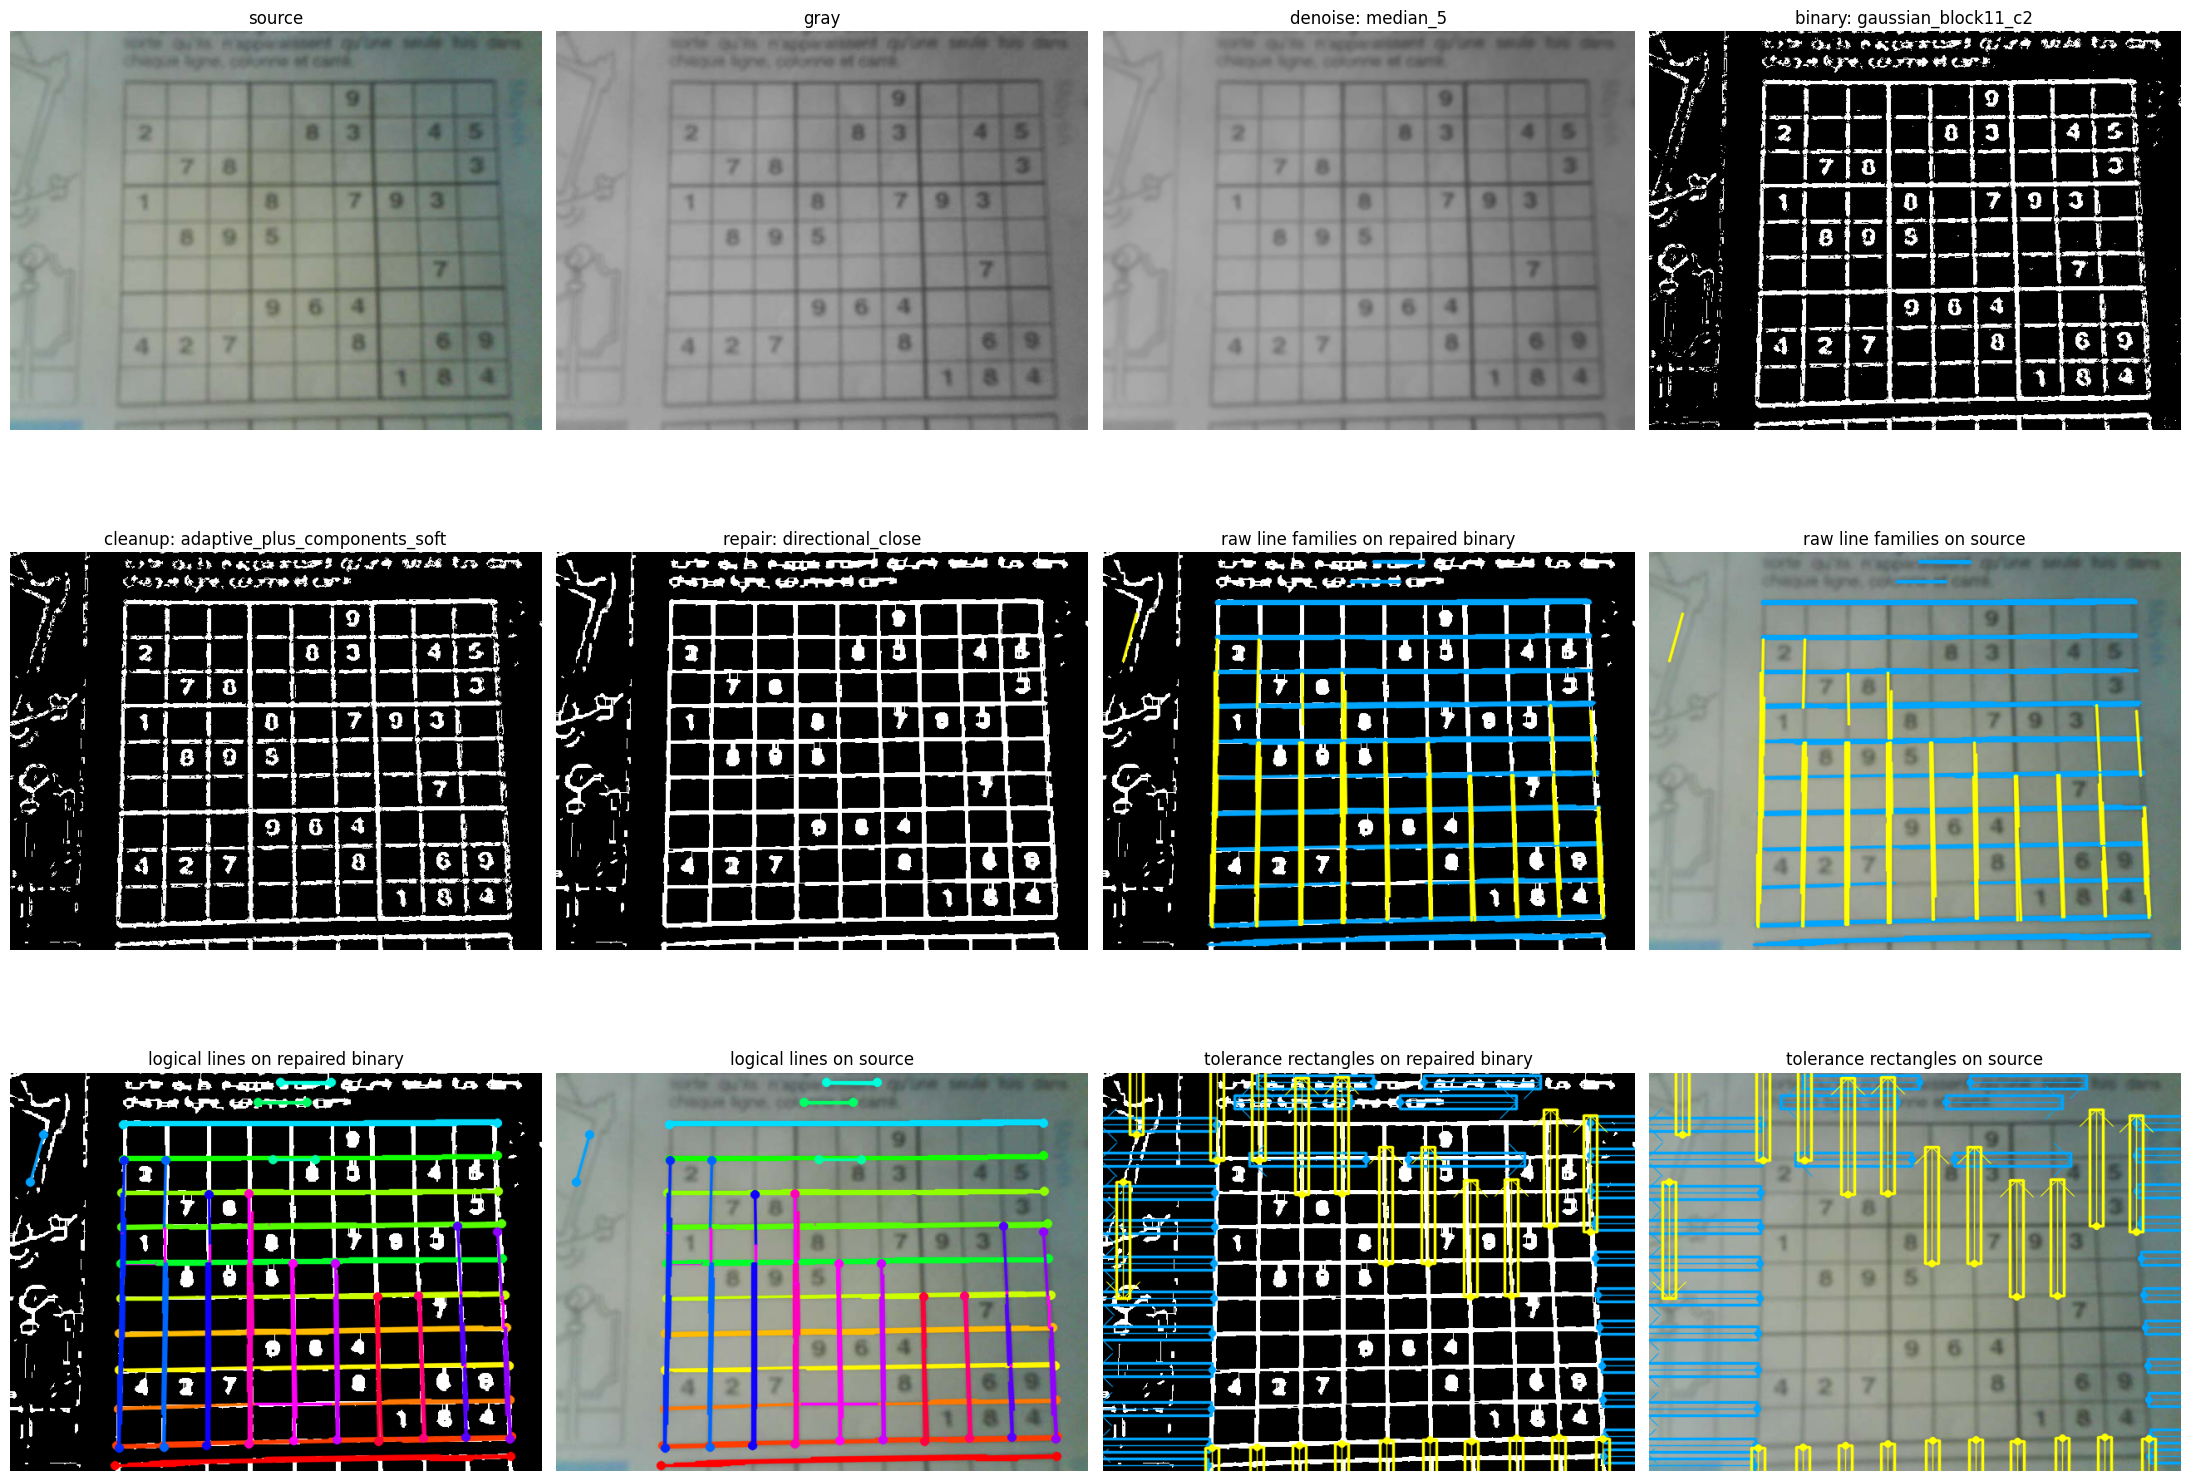

In [14]:
RAW_LINE_FAMILY_PLOT_ITEMS = build_raw_line_family_plot_items(ARTIFACTS)

API.plot_named_images(
    RAW_LINE_FAMILY_PLOT_ITEMS,
    columns=4,
    figure_scale=5.5,
)